In [72]:
%load_ext autoreload
%autoreload 2

import glob
import os
import sys

import contextily as cx
import numpy as np
import torch

from meadow.climate import download_climate_layers
from meadow.io import list_species, load_species
from meadow.train import build_species_graphs, train_model
from meadow.viz import plot_multi_edge_resistance, plot_shared_resistance, plot_sites

torch.set_default_dtype(torch.float64)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
PEDIC_DIR = '/Users/isaac/src/meems/pedic_feems_files'

species_list = load_species(PEDIC_DIR)
print([s.name for s in species_list])


['anas_feems', 'brevi_feems', 'crano_feems', 'densis_feems', 'integ_feems', 'kansu_feems', 'lachno_feems', 'longi_feems', 'rhinanth_feems', 'szet_feems', 'tenu_feems', 'vert_feems']


Mesh spacing (km) = 21.837552994388965


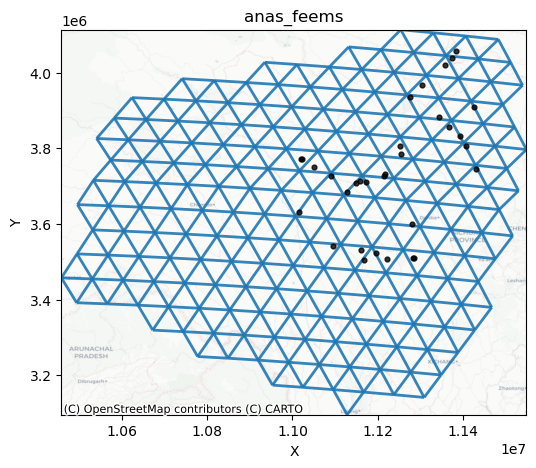

In [71]:
raster_paths = glob.glob('/Users/isaac/.cache/meadow/climate/bioclim/wc2.1/2.5m/bio/*.tif')

graphs, stats = build_species_graphs(
    species_list,
    mesh_builder="geodesic",
    #mesh_spacing_km=50,
    raster_paths=raster_paths,
)
_ = graphs[0].plot()

In [45]:
model = train_model(graphs, edge_smoothing=0.6)

epoch   25 loss 0.296916 val 0.023675
epoch   50 loss 0.201876 val 0.016233
epoch   75 loss 0.167496 val 0.013655
epoch  100 loss 0.156203 val 0.012886
epoch  125 loss 0.152391 val 0.012649
epoch  150 loss 0.150624 val 0.012532
early stop at epoch 170 val 0.012473 best 0.012568


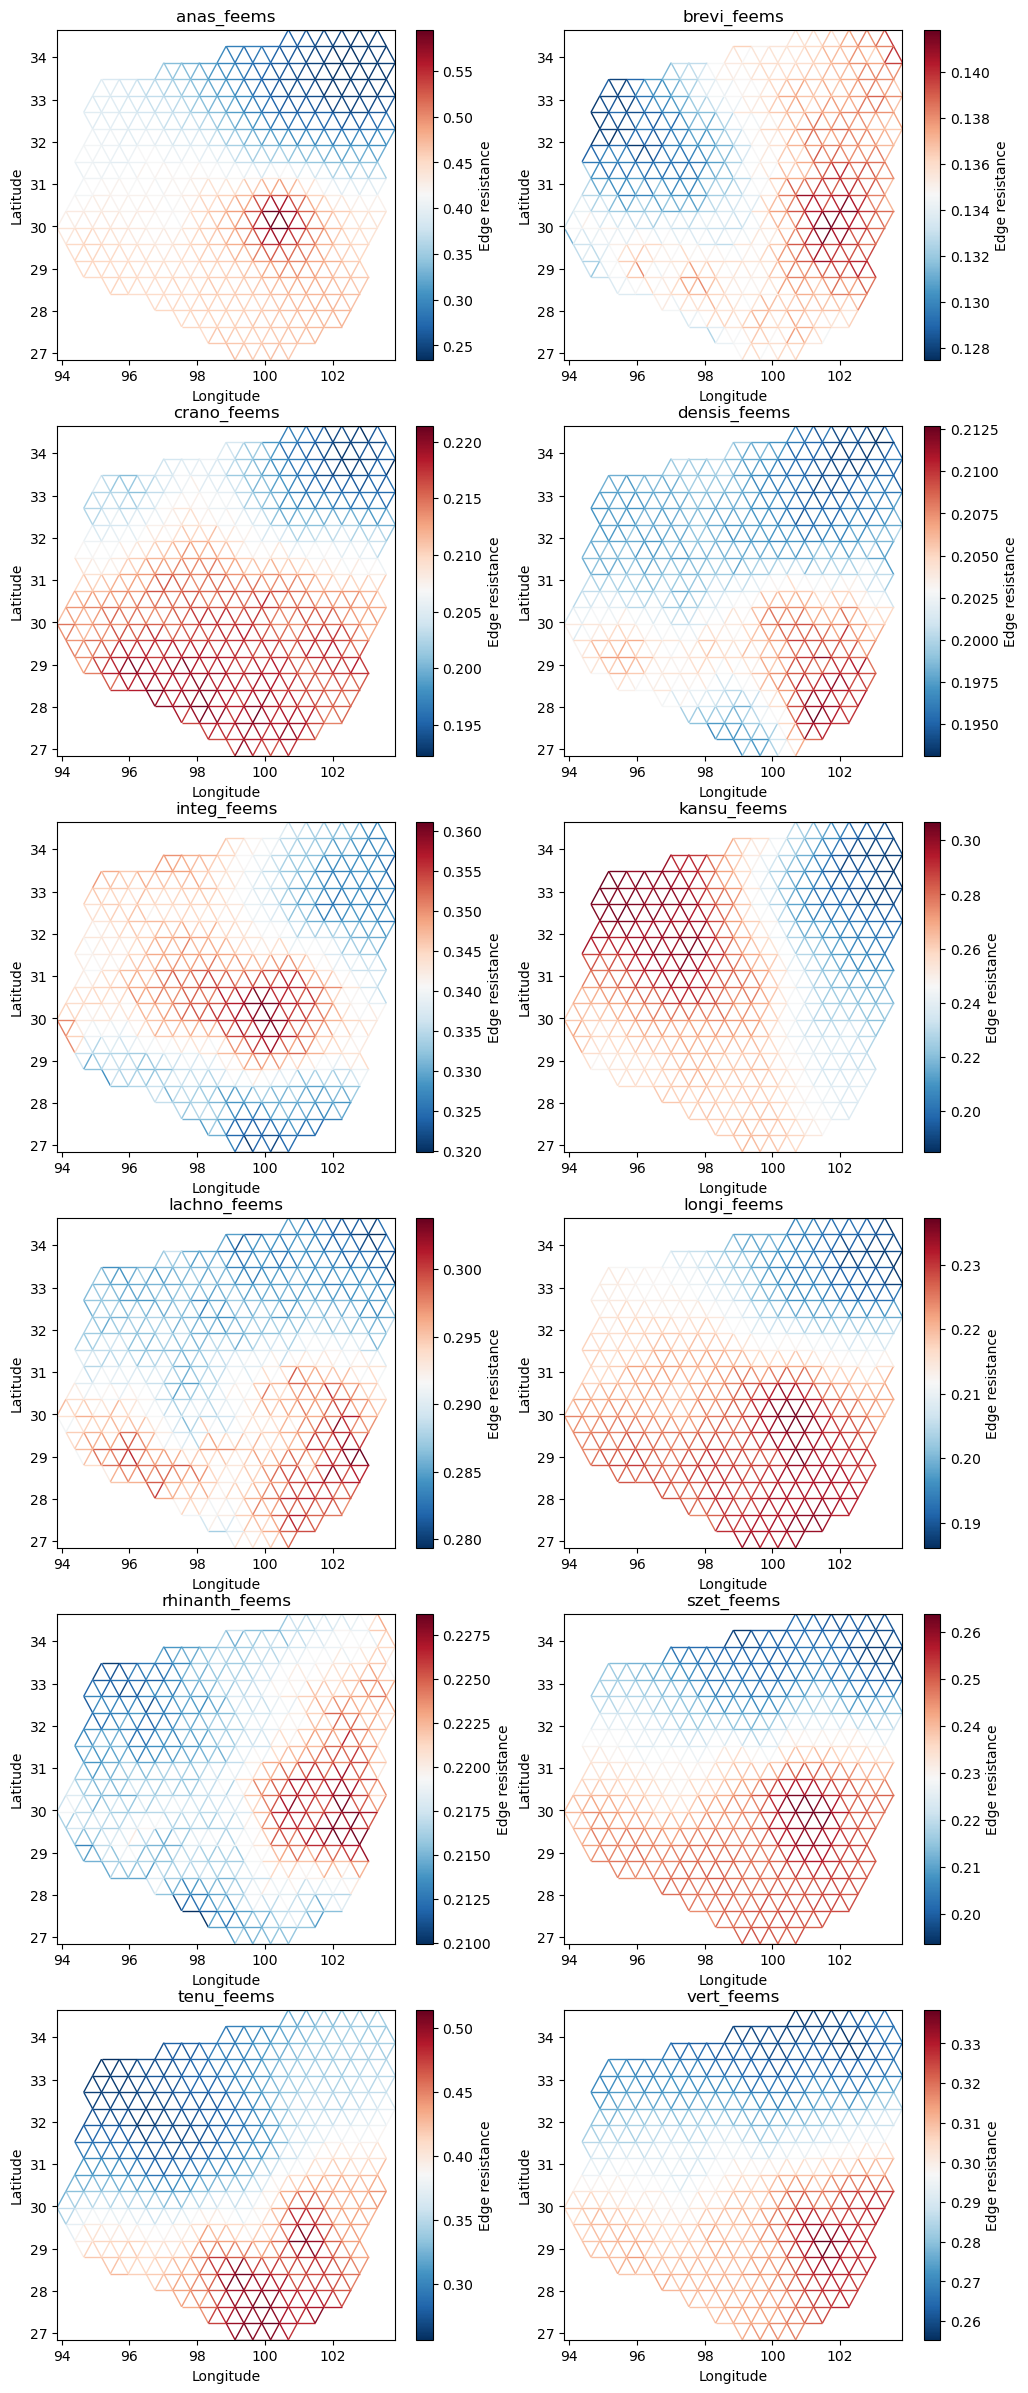

In [50]:
# Multi-species edge resistances (subplot grid)
_ = plot_multi_edge_resistance(
    species_list,
    graphs,
    model,
    basemap=False,#"USGS.USTopo",
    show_sites=True,
    explore=True,
)
